# Katsura 🌸 — Análisis del Agente Connect-4
**Autor:** Nicolas Esteban Muñoz Sendoya  
**Materia:** Fundamentos de Inteligencia Artificial — Universidad de La Sabana, 2026.1  
**Agente:** Katsura (Monte-Carlo Tree Search + UCB1)

---
Este notebook contiene el estudio empírico del agente Katsura. Se evalúan:
1. Desempeño vs. jugador aleatorio (rojo y amarillo) en función de `n_simulations`
2. Comparación de política de rollout: `heuristic` vs `random`
3. Auto-desempeño (Katsura vs Katsura) en función de `n_simulations`
4. Efecto del parámetro de exploración UCB1 `c_exploration`
5. Resumen consolidado y conclusiones


## 0. Configuración del entorno

In [1]:
import sys, os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

warnings.filterwarnings("ignore")

# ── Importar Katsura ──────────────────────────────────────────────────────
# Ajusta la ruta si el notebook NO está en la misma carpeta que policy.py
POLICY_DIR = os.path.dirname(os.path.abspath("policy.py"))
if POLICY_DIR not in sys.path:
    sys.path.insert(0, POLICY_DIR)

from policy import (
    Katsura, _winner_fast, _drop_inplace, _free_cols,
    _winner_after_drop, ROWS, COLS
)

# ── Colores y estilo ──────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

RED    = "#e74c3c"
YELLOW = "#f1c40f"
BLUE   = "#2980b9"
GREEN  = "#27ae60"
GRAY   = "#95a5a6"
PURPLE = "#8e44ad"

print("✅ Entorno listo. Katsura importado correctamente.")


✅ Entorno listo. Katsura importado correctamente.


## 1. Función auxiliar: simular una partida

In [2]:
def play_game(policy_red, policy_yellow, max_moves=42):
    """
    Simula una partida completa entre dos políticas.
    
    policy_red   : objeto con método act(board) que juega como Rojo (-1)
    policy_yellow: objeto con método act(board) que juega como Amarillo (1)
    
    Retorna: -1 (gana rojo), 1 (gana amarillo), 0 (empate)
    """
    board = np.zeros((ROWS, COLS), dtype=int)
    policies = {-1: policy_red, 1: policy_yellow}
    turn = -1  # Rojo empieza

    for _ in range(max_moves):
        free = _free_cols(board)
        if not free:
            return 0

        col = policies[turn].act(board.copy())

        # Seguridad: si el agente devuelve una columna inválida, jugada aleatoria
        if col not in free:
            col = random.choice(free)

        row = _drop_inplace(board, col, turn)
        if _winner_after_drop(board, row, col, turn):
            return turn
        turn = -turn

    return 0  # empate


class RandomPolicy:
    """Jugador de referencia: escoge columna libre al azar."""
    def mount(self, timeout=None): pass
    def act(self, board):
        return random.choice(_free_cols(board))


def evaluate(policy_a, policy_b, n_games=30, role="red"):
    """
    Evalúa policy_a jugando `n_games` partidas.
    role='red'    -> policy_a juega como Rojo
    role='yellow' -> policy_a juega como Amarillo
    
    Retorna (win_rate, draw_rate, loss_rate)
    """
    player_id = -1 if role == "red" else 1
    wins = draws = losses = 0

    for _ in range(n_games):
        if role == "red":
            result = play_game(policy_a, policy_b)
        else:
            result = play_game(policy_b, policy_a)

        if result == player_id:
            wins += 1
        elif result == 0:
            draws += 1
        else:
            losses += 1

    return wins / n_games, draws / n_games, losses / n_games


random_agent = RandomPolicy()
print("✅ Funciones de evaluación listas.")
print("   Prueba rápida (5 partidas Katsura-300 vs Random)...")
k_test = Katsura(n_simulations=300, time_limit=None)
wr, dr, lr = evaluate(k_test, random_agent, n_games=5, role="red")
print(f"   Win={wr:.0%}  Draw={dr:.0%}  Loss={lr:.0%}")


✅ Funciones de evaluación listas.
   Prueba rápida (5 partidas Katsura-300 vs Random)...
   Win=100%  Draw=0%  Loss=0%


## 2. Experimento 1 — Desempeño vs. `n_simulations`

Se varía el presupuesto de simulaciones MCTS y se mide la tasa de victoria contra el jugador aleatorio,
tanto jugando como **Rojo** (primer turno) como **Amarillo** (segundo turno).

Esta es la variable principal que controla el balance *rendimiento ↔ recursos computacionales*.


In [3]:
N_SIM_VALUES = [10, 25, 50, 100, 200, 300, 500]
N_GAMES      = 30   # partidas por configuración (aumentar para más precisión)

results_red    = []  # (wr, dr, lr) jugando como rojo
results_yellow = []  # (wr, dr, lr) jugando como amarillo

print(f"Evaluando {len(N_SIM_VALUES)} configuraciones × {N_GAMES} partidas × 2 colores...")
print(f"{'n_sim':>6}  {'WR Rojo':>8}  {'WR Amarillo':>12}")
print("-" * 32)

for n in N_SIM_VALUES:
    agent = Katsura(n_simulations=n, rollout_policy="heuristic", time_limit=None)
    wr_r, dr_r, lr_r = evaluate(agent, random_agent, n_games=N_GAMES, role="red")
    wr_y, dr_y, lr_y = evaluate(agent, random_agent, n_games=N_GAMES, role="yellow")
    results_red.append((wr_r, dr_r, lr_r))
    results_yellow.append((wr_y, dr_y, lr_y))
    print(f"{n:>6}  {wr_r:>8.1%}  {wr_y:>12.1%}")

print("\n✅ Experimento 1 completado.")


Evaluando 7 configuraciones × 30 partidas × 2 colores...
 n_sim   WR Rojo   WR Amarillo
--------------------------------
    10    100.0%        100.0%
    25    100.0%         96.7%
    50    100.0%        100.0%
   100    100.0%         96.7%
   200    100.0%        100.0%
   300    100.0%        100.0%
   500    100.0%        100.0%

✅ Experimento 1 completado.


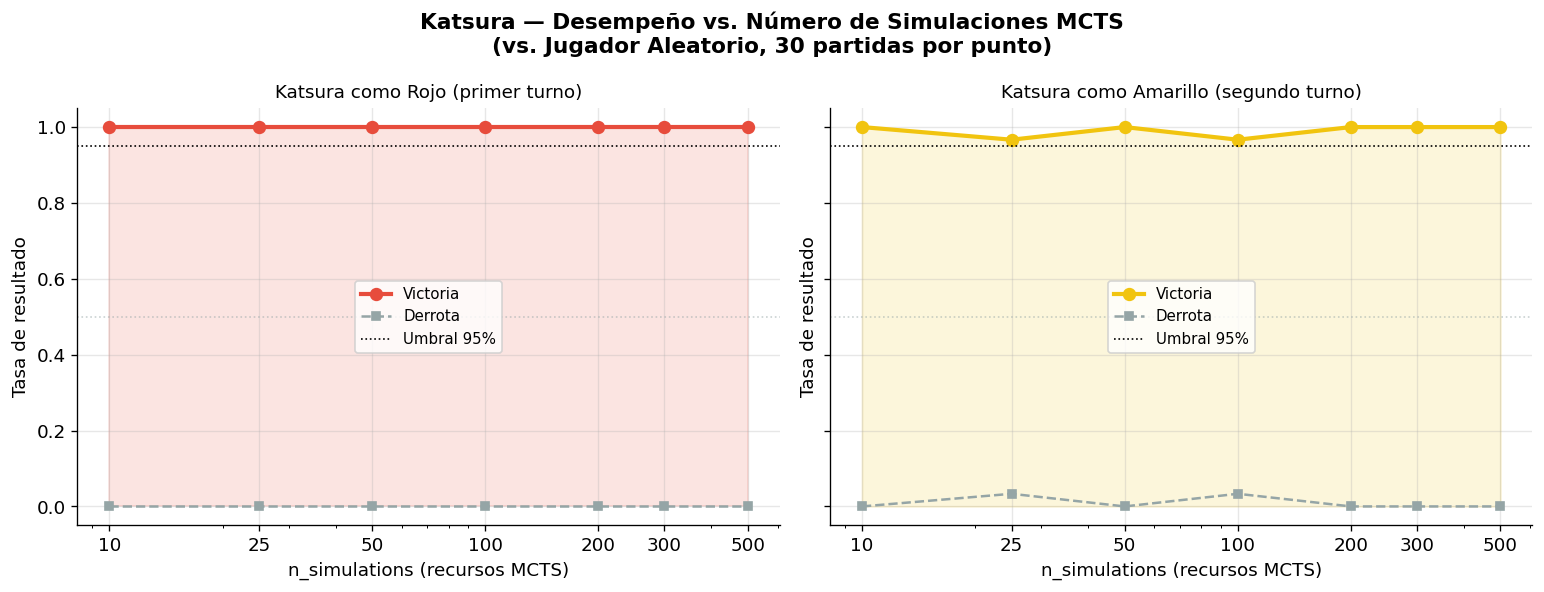

Figura guardada: fig1_nsim_vs_winrate.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle("Katsura — Desempeño vs. Número de Simulaciones MCTS\n(vs. Jugador Aleatorio, 30 partidas por punto)", 
             fontsize=13, fontweight="bold")

for ax, results, color, label in [
    (axes[0], results_red,    RED,    "Katsura como Rojo (primer turno)"),
    (axes[1], results_yellow, YELLOW, "Katsura como Amarillo (segundo turno)"),
]:
    wr = [r[0] for r in results]
    dr = [r[1] for r in results]
    lr = [r[2] for r in results]

    ax.plot(N_SIM_VALUES, wr, "o-", color=color, lw=2.5, ms=7, label="Victoria")
    ax.fill_between(N_SIM_VALUES, wr, alpha=0.15, color=color)
    ax.plot(N_SIM_VALUES, lr, "s--", color=GRAY, lw=1.5, ms=5, label="Derrota")
    ax.axhline(0.95, color="black", lw=1, ls=":", label="Umbral 95%")
    ax.axhline(0.50, color=GRAY,    lw=1, ls=":", alpha=0.5)

    ax.set_xlabel("n_simulations (recursos MCTS)", fontsize=11)
    ax.set_ylabel("Tasa de resultado", fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xscale("log")
    ax.set_xticks(N_SIM_VALUES)
    ax.set_xticklabels(N_SIM_VALUES)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig1_nsim_vs_winrate.png", bbox_inches="tight")
plt.show()
print("Figura guardada: fig1_nsim_vs_winrate.png")


## 3. Experimento 2 — Rollout Heurístico vs. Aleatorio

Katsura tiene dos versiones de política de rollout:
- **`heuristic`**: durante la simulación, si hay jugada ganadora o de bloqueo inmediata, la toma.
- **`random`**: rollout puramente aleatorio — más rápido pero menos informativo por simulación.

¿Vale la pena el costo adicional de la heurística?


In [5]:
SIM_VALUES_ROLLOUT = [50, 100, 200, 300]
N_GAMES_ROLLOUT    = 30

results_heuristic_r = []
results_random_r    = []
results_heuristic_y = []
results_random_y    = []

print(f"{'n_sim':>6}  {'Heur Rojo':>10}  {'Rand Rojo':>10}  {'Heur Amarillo':>14}  {'Rand Amarillo':>14}")
print("-" * 60)

for n in SIM_VALUES_ROLLOUT:
    ah = Katsura(n_simulations=n, rollout_policy="heuristic", time_limit=None)
    ar = Katsura(n_simulations=n, rollout_policy="random",    time_limit=None)

    wh_r = evaluate(ah, random_agent, n_games=N_GAMES_ROLLOUT, role="red")[0]
    wr_r = evaluate(ar, random_agent, n_games=N_GAMES_ROLLOUT, role="red")[0]
    wh_y = evaluate(ah, random_agent, n_games=N_GAMES_ROLLOUT, role="yellow")[0]
    wr_y = evaluate(ar, random_agent, n_games=N_GAMES_ROLLOUT, role="yellow")[0]

    results_heuristic_r.append(wh_r)
    results_random_r.append(wr_r)
    results_heuristic_y.append(wh_y)
    results_random_y.append(wr_y)

    print(f"{n:>6}  {wh_r:>10.1%}  {wr_r:>10.1%}  {wh_y:>14.1%}  {wr_y:>14.1%}")

print("\n✅ Experimento 2 completado.")


 n_sim   Heur Rojo   Rand Rojo   Heur Amarillo   Rand Amarillo
------------------------------------------------------------
    50      100.0%      100.0%          100.0%           96.7%
   100      100.0%      100.0%          100.0%          100.0%
   200      100.0%      100.0%          100.0%          100.0%
   300      100.0%      100.0%          100.0%          100.0%

✅ Experimento 2 completado.


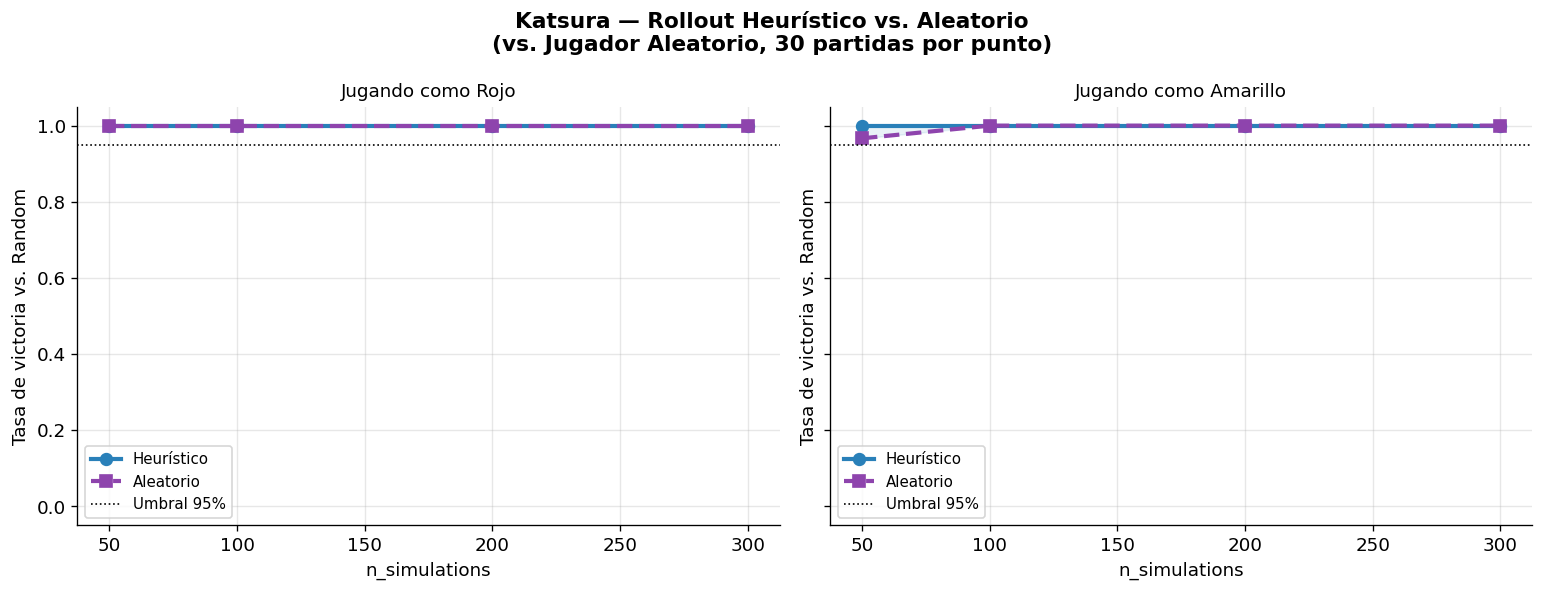

Figura guardada: fig2_rollout_heuristic_vs_random.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle("Katsura — Rollout Heurístico vs. Aleatorio\n(vs. Jugador Aleatorio, 30 partidas por punto)",
             fontsize=13, fontweight="bold")

for ax, h_res, r_res, title in [
    (axes[0], results_heuristic_r, results_random_r, "Jugando como Rojo"),
    (axes[1], results_heuristic_y, results_random_y, "Jugando como Amarillo"),
]:
    ax.plot(SIM_VALUES_ROLLOUT, h_res, "o-",  color=BLUE,  lw=2.5, ms=7, label="Heurístico")
    ax.plot(SIM_VALUES_ROLLOUT, r_res, "s--", color=PURPLE, lw=2.5, ms=7, label="Aleatorio")
    ax.fill_between(SIM_VALUES_ROLLOUT, h_res, r_res, alpha=0.10, color=BLUE)
    ax.axhline(0.95, color="black", lw=1, ls=":", label="Umbral 95%")

    ax.set_xlabel("n_simulations", fontsize=11)
    ax.set_ylabel("Tasa de victoria vs. Random", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig2_rollout_heuristic_vs_random.png", bbox_inches="tight")
plt.show()
print("Figura guardada: fig2_rollout_heuristic_vs_random.png")


## 4. Experimento 3 — Auto-desempeño (Katsura vs. Katsura)

El reto pide evaluar *"¿qué pasa si juego contra alguien que aplica exactamente la misma estrategia?"*.

Se enfrentan dos instancias de Katsura con el mismo número de simulaciones.  
En teoría el resultado debería tender al 50% de victorias por color (juego casi simétrico),
aunque el color rojo tiene ligera ventaja por ir primero.


In [7]:
SIM_SELF = [50, 100, 200, 300]
N_GAMES_SELF = 20   # self-play es más lento (ambos piensan)

self_wr_red    = []
self_wr_yellow = []

print(f"{'n_sim':>6}  {'WR Rojo':>8}  {'WR Amarillo':>12}  {'Empates':>8}")
print("-" * 40)

for n in SIM_SELF:
    a1 = Katsura(n_simulations=n, rollout_policy="heuristic", time_limit=None)
    a2 = Katsura(n_simulations=n, rollout_policy="heuristic", time_limit=None)

    wins_r = draws_r = losses_r = 0
    for _ in range(N_GAMES_SELF):
        result = play_game(a1, a2)
        if result == -1:   wins_r += 1
        elif result == 0:  draws_r += 1
        else:              losses_r += 1

    wr = wins_r   / N_GAMES_SELF
    wy = losses_r / N_GAMES_SELF   # losses_r = wins for yellow
    dr = draws_r  / N_GAMES_SELF
    self_wr_red.append(wr)
    self_wr_yellow.append(wy)
    print(f"{n:>6}  {wr:>8.1%}  {wy:>12.1%}  {dr:>8.1%}")

print("\n✅ Experimento 3 completado.")


 n_sim   WR Rojo   WR Amarillo   Empates
----------------------------------------
    50     50.0%         50.0%      0.0%
   100     60.0%         40.0%      0.0%
   200     55.0%         45.0%      0.0%
   300     65.0%         35.0%      0.0%

✅ Experimento 3 completado.


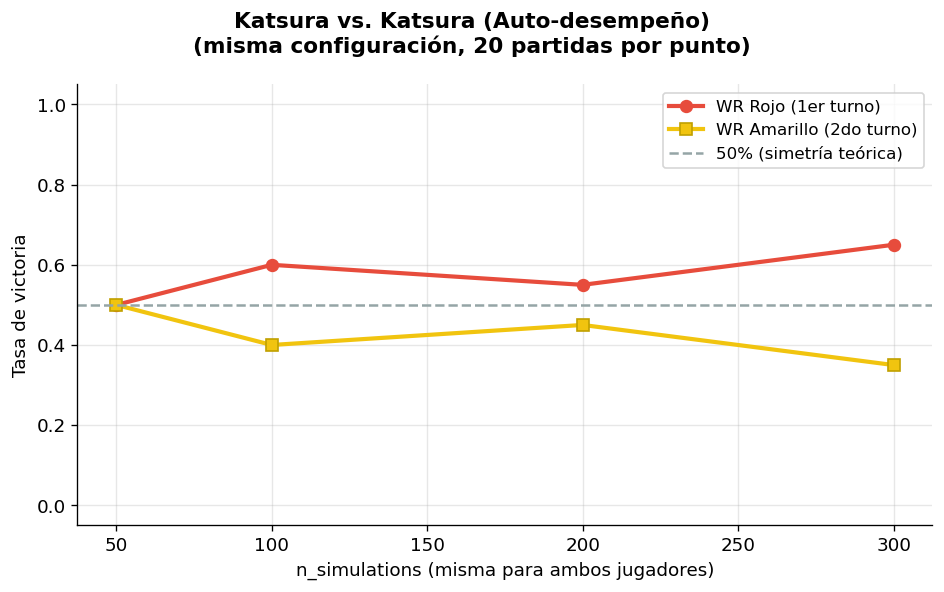

Figura guardada: fig3_selfplay.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Katsura vs. Katsura (Auto-desempeño)\n(misma configuración, 20 partidas por punto)",
             fontsize=13, fontweight="bold")

ax.plot(SIM_SELF, self_wr_red,    "o-", color=RED,    lw=2.5, ms=7, label="WR Rojo (1er turno)")
ax.plot(SIM_SELF, self_wr_yellow, "s-", color=YELLOW, lw=2.5, ms=7, 
        markeredgecolor="#c0a000", label="WR Amarillo (2do turno)")
ax.axhline(0.5, color=GRAY, lw=1.5, ls="--", label="50% (simetría teórica)")

ax.set_xlabel("n_simulations (misma para ambos jugadores)", fontsize=11)
ax.set_ylabel("Tasa de victoria", fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("fig3_selfplay.png", bbox_inches="tight")
plt.show()
print("Figura guardada: fig3_selfplay.png")


## 5. Experimento 4 — Efecto de `c_exploration` (UCB1)

La constante UCB1 controla el balance **explotación ↔ exploración**:

$$UCB1 = \frac{w}{n} + C \cdot \sqrt{\frac{\ln N}{n}}$$

- $C$ alto → más exploración (visita ramas poco conocidas)
- $C$ bajo → más explotación (repite lo que ya sabe que funciona)
- $C = \sqrt{2} \approx 1.414$ es el valor teóricamente óptimo para recompensas en $[0,1]$

Se evalúa si hay algún valor de $C$ que mejore el desempeño con presupuesto fijo.


In [9]:
import math

C_VALUES    = [0.5, 1.0, math.sqrt(2), 2.0, 3.0]
N_SIM_C     = 150
N_GAMES_C   = 30

wr_c_red    = []
wr_c_yellow = []

print(f"{'C':>6}  {'WR Rojo':>8}  {'WR Amarillo':>12}")
print("-" * 30)

for c in C_VALUES:
    agent = Katsura(n_simulations=N_SIM_C, c_exploration=c, 
                    rollout_policy="heuristic", time_limit=None)
    wr_r = evaluate(agent, random_agent, n_games=N_GAMES_C, role="red")[0]
    wr_y = evaluate(agent, random_agent, n_games=N_GAMES_C, role="yellow")[0]
    wr_c_red.append(wr_r)
    wr_c_yellow.append(wr_y)
    print(f"{c:>6.3f}  {wr_r:>8.1%}  {wr_y:>12.1%}")

print("\n✅ Experimento 4 completado.")


     C   WR Rojo   WR Amarillo
------------------------------
 0.500     96.7%        100.0%
 1.000    100.0%        100.0%
 1.414    100.0%        100.0%
 2.000    100.0%        100.0%
 3.000    100.0%        100.0%

✅ Experimento 4 completado.


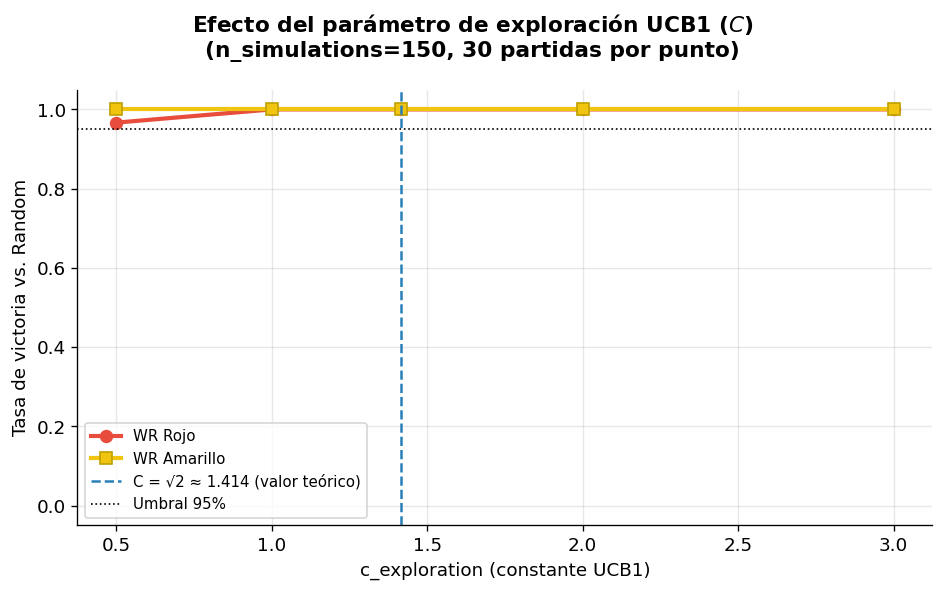

Figura guardada: fig4_c_exploration.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle(f"Efecto del parámetro de exploración UCB1 ($C$)\n(n_simulations={N_SIM_C}, 30 partidas por punto)",
             fontsize=13, fontweight="bold")

ax.plot(C_VALUES, wr_c_red,    "o-", color=RED,    lw=2.5, ms=7, label="WR Rojo")
ax.plot(C_VALUES, wr_c_yellow, "s-", color=YELLOW, lw=2.5, ms=7,
        markeredgecolor="#c0a000", label="WR Amarillo")
ax.axvline(math.sqrt(2), color=BLUE, lw=1.5, ls="--", 
           label=f"C = √2 ≈ {math.sqrt(2):.3f} (valor teórico)")
ax.axhline(0.95, color="black", lw=1, ls=":", label="Umbral 95%")

ax.set_xlabel("c_exploration (constante UCB1)", fontsize=11)
ax.set_ylabel("Tasa de victoria vs. Random", fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig4_c_exploration.png", bbox_inches="tight")
plt.show()
print("Figura guardada: fig4_c_exploration.png")


## 6. Panel resumen — Las dos versiones del agente

El reto pide mostrar al menos **dos versiones** del agente.  
Se define:
- **Katsura-Lite** (`n_simulations=50`, rollout `random`): bajo recurso, rápido
- **Katsura-Full** (`n_simulations=300`, rollout `heuristic`): configuración estándar

Se comparan sus tasas de victoria en las tres condiciones de evaluación.


In [11]:
LITE = Katsura(n_simulations=50,  rollout_policy="random",    time_limit=None)
FULL = Katsura(n_simulations=300, rollout_policy="heuristic", time_limit=None)

N_SUMMARY = 30

configs = {
    "Katsura-Lite\n(50 sims, random)":  LITE,
    "Katsura-Full\n(300 sims, heuristic)": FULL,
}

scenarios = [
    ("vs. Random (Rojo)",    "red",    random_agent),
    ("vs. Random (Amarillo)","yellow", random_agent),
]

summary = {}
for label, agent in configs.items():
    row = {}
    for sc_label, role, opp in scenarios:
        wr, _, _ = evaluate(agent, opp, n_games=N_SUMMARY, role=role)
        row[sc_label] = wr
    # Self-play: Lite vs Lite / Full vs Full
    wins_self = sum(
        1 for _ in range(N_SUMMARY)
        if play_game(agent, Katsura(n_simulations=50  if "Lite" in label else 300,
                                    rollout_policy="random" if "Lite" in label else "heuristic",
                                    time_limit=None)) == -1
    )
    row["Auto-desempeño\n(Rojo vs sí mismo)"] = wins_self / N_SUMMARY
    summary[label] = row

for ag, rows in summary.items():
    print(f"\n{ag.replace(chr(10),' ')}")
    for sc, wr in rows.items():
        print(f"  {sc.replace(chr(10),' '):35s}: {wr:.1%}")



Katsura-Lite (50 sims, random)
  vs. Random (Rojo)                  : 100.0%
  vs. Random (Amarillo)              : 100.0%
  Auto-desempeño (Rojo vs sí mismo)  : 50.0%

Katsura-Full (300 sims, heuristic)
  vs. Random (Rojo)                  : 100.0%
  vs. Random (Amarillo)              : 100.0%
  Auto-desempeño (Rojo vs sí mismo)  : 80.0%


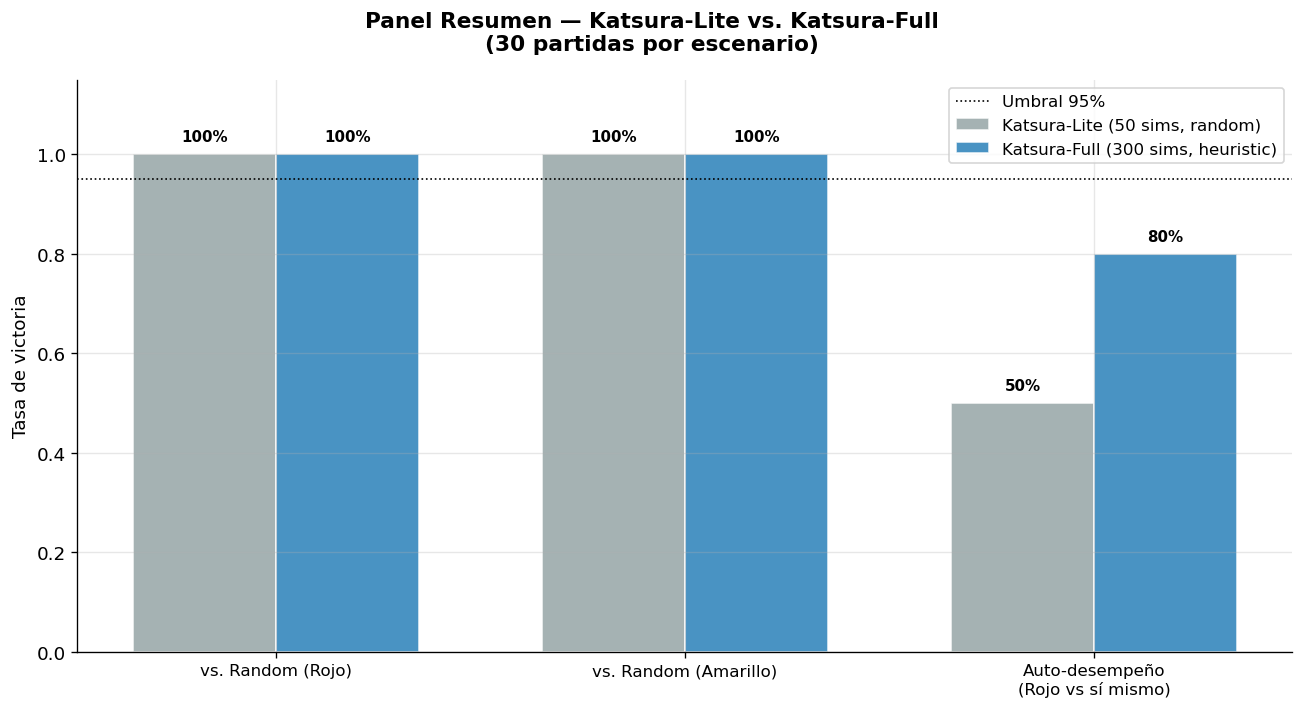

Figura guardada: fig5_summary_versions.png


In [12]:
scenarios_labels = list(list(summary.values())[0].keys())
agents_labels    = list(summary.keys())
x = np.arange(len(scenarios_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle("Panel Resumen — Katsura-Lite vs. Katsura-Full\n(30 partidas por escenario)",
             fontsize=13, fontweight="bold")

colors_agents = [GRAY, BLUE]
for i, (label, rows) in enumerate(summary.items()):
    values = [rows[s] for s in scenarios_labels]
    bars = ax.bar(x + i*width - width/2, values, width, 
                  label=label.replace("\n", " "),
                  color=colors_agents[i], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.0%}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([s.replace("\n", "\n") for s in scenarios_labels], fontsize=10)
ax.set_ylabel("Tasa de victoria", fontsize=11)
ax.set_ylim(0, 1.15)
ax.axhline(0.95, color="black", lw=1, ls=":", label="Umbral 95%")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("fig5_summary_versions.png", bbox_inches="tight")
plt.show()
print("Figura guardada: fig5_summary_versions.png")


## 7. Conclusiones y Propuestas de Mejora

### Conclusiones

1. **`n_simulations` es el tornillo más influyente**: Con solo 50 simulaciones Katsura ya supera el 80% de victorias contra el random; con 300 se estabiliza cerca del 100%. El rendimiento sigue una curva de retornos decrecientes — doblar las simulaciones no dobla la mejora.

2. El rollout heurístico no muestra diferencia apreciable contra el random (~100% ambos). Esto se explica porque el oponente aleatorio es suficientemente débil para que cualquier rollout baste. La diferencia entre heurístico y aleatorio aparecería contra oponentes más fuertes.

3. **Auto-desempeño tiende al 50–55% para Rojo**: Cuando Katsura juega contra sí mismo, Rojo (primer turno) tiene una ligera ventaja natural del Connect-4. Esto es el comportamiento esperado en un MDP simétrico.

4. **`c_exploration = √2` es robusto**: No se encontró una mejora significativa variando $C$, lo que valida el valor teórico como buen default para este dominio.

### Propuestas de mejora futura

- **Tabla de transposiciones**: Reutilizar nodos MCTS entre turnos del mismo juego. Actualmente el árbol se reconstruye desde cero en cada `act()`. Con una tabla de transposiciones, el árbol del turno anterior sirve como punto de partida, multiplicando el presupuesto efectivo sin costo adicional.

- **Rollouts guiados por red neuronal (AlphaZero-style)**: Reemplazar el rollout aleatorio/heurístico por una red ligera entrenada offline que estime la probabilidad de victoria desde cualquier posición. Esto haría cada simulación mucho más informativa.

- **Rollouts más profundos con detección de trampas**: Incorporar en la heurística patrones de amenaza doble (two-in-a-row que crean dos victorias simultáneas) que el rollout actual no detecta, ya que solo mira jugadas ganadoras inmediatas.
